In [ ]:
import plotly.express as px
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os

import matplotlib
matplotlib.use('Agg')


def save_matplotlib_figure(fig, filename):
    fig.tight_layout()
    fig.savefig(filename, dpi=150)
    plt.close(fig)


out_dir = '/workspaces/Visualizations/tips_outputs'
os.makedirs(out_dir, exist_ok=True)

# https://github.com/mwaskom/seaborn-data/blob/master/tips.csv
tips = sns.load_dataset('tips')
print('Tips dataset shape:', tips.shape)
print('Columns:', list(tips.columns))
print(tips.head().to_string(index=False))

Tips dataset shape: (244, 7)
Columns: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']
 total_bill  tip    sex smoker day   time  size
      16.99 1.01 Female     No Sun Dinner     2
      10.34 1.66   Male     No Sun Dinner     3
      21.01 3.50   Male     No Sun Dinner     3
      23.68 3.31   Male     No Sun Dinner     2
      24.59 3.61 Female     No Sun Dinner     4


In [ ]:
# Matplotlib graphs
fig, ax = plt.subplots(figsize=(8, 5))

by_day = tips.groupby('day', as_index=False)['total_bill'].mean()
print(by_day.head().to_string(index=False))
ax.plot(by_day['day'], by_day['total_bill'],
        marker='o', color='royalblue', linewidth=2)
ax.set_title('Matplotlib - Average Bill by Day')
ax.set_xlabel('Day')
ax.set_ylabel('Average Total Bill')
ax.grid(True, alpha=0.3)
save_matplotlib_figure(fig, os.path.join(out_dir, 'matplotlib_line.png'))


/tmp/ipykernel_3371/2596773963.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_day = tips.groupby('day', as_index=False)['total_bill'].mean()


 day  total_bill
Thur   17.682742
 Fri   17.151579
 Sat   20.441379
 Sun   21.410000


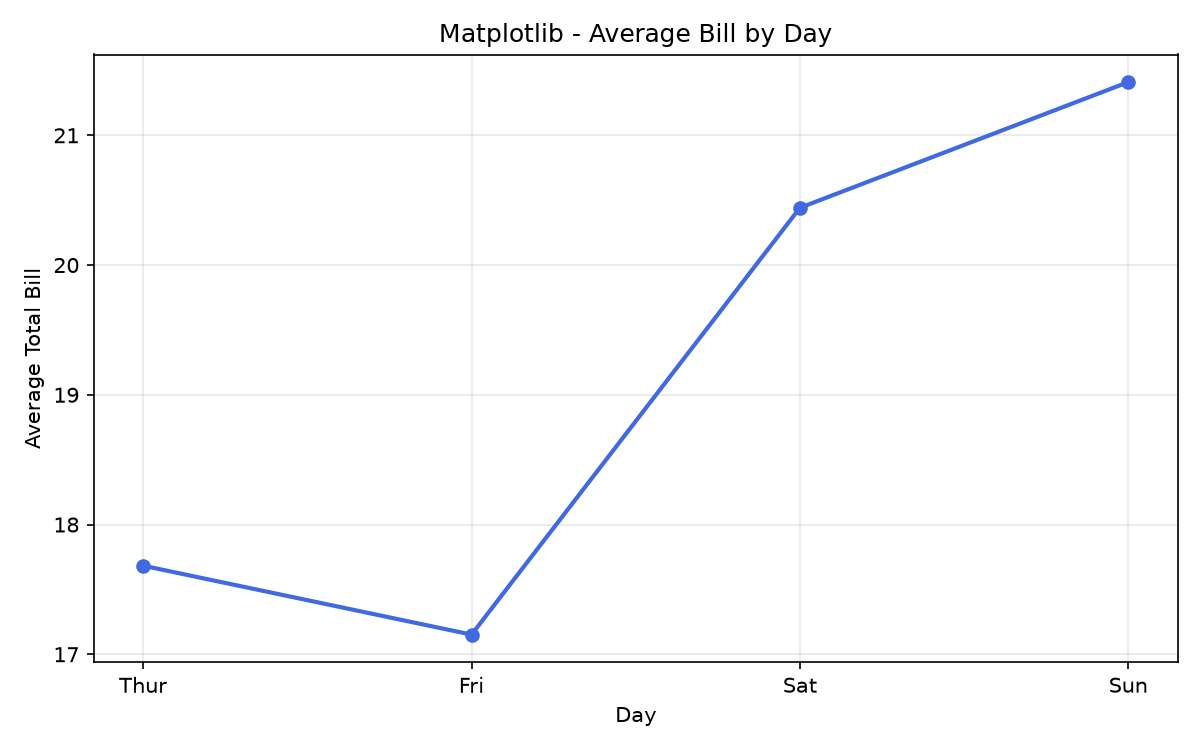

### Short Insights – Matplotlib Line Chart

* **Sunday has the highest average total bill**, at approximately **21.4**.
* **Saturday** has the second-highest average bill, at approximately **20.4**.
* **Thursday** has an average bill of approximately **17.7**.
* **Friday has the lowest average total bill**, at approximately **17.2**.
* There is a **significant increase in average bill from Friday to Saturday**.
* Overall, the average bill is **higher on weekends (Saturday and Sunday)** compared with Thursday and Friday.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
by_day = tips.groupby('day', as_index=False)['total_bill'].mean()
ax.bar(by_day['day'], by_day['total_bill'], color='seagreen')
ax.set_title('Matplotlib - Bar Chart of Average Bill by Day')
ax.set_xlabel('Day')
ax.set_ylabel('Average Total Bill')
for i, value in enumerate(by_day['total_bill']):
    ax.text(i, value + 2, f'{value:.1f}', ha='center')
save_matplotlib_figure(fig, os.path.join(out_dir, 'matplotlib_bar.png'))

/tmp/ipykernel_3371/3579487929.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_day = tips.groupby('day', as_index=False)['total_bill'].mean()


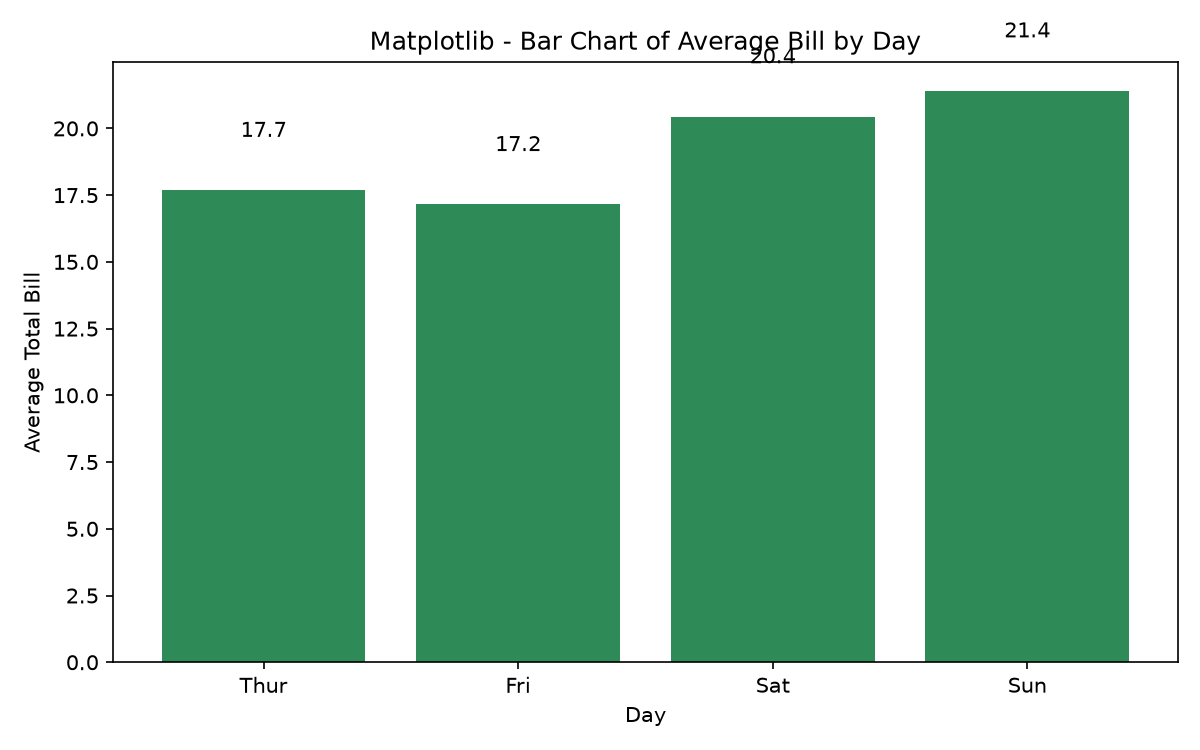

### Short Insights – Matplotlib Bar Chart

* **Sunday** has the highest average bill at approximately **21.4**.
* **Saturday** is the second-highest at approximately **20.4**.
* **Thursday** has an average bill of approximately **17.7**.
* **Friday** has the lowest average bill at approximately **17.2**.
* Average bills are **higher on Saturday and Sunday** compared with Thursday and Friday.
* The difference between the **lowest (Friday)** and **highest (Sunday)** average bill is about **4.3**.


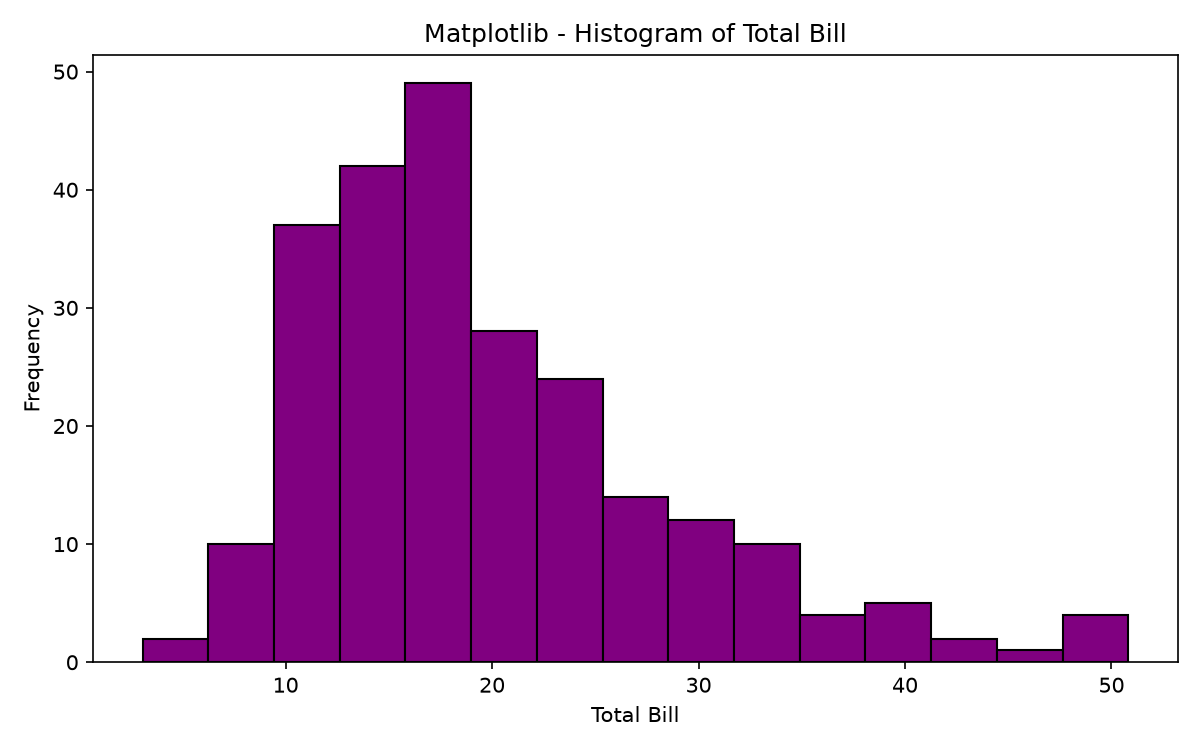

### Short Insights – Matplotlib Histogram

* Most total bills are concentrated between approximately **$10 and $25**.

* The highest frequency occurs around the **$15–$20** range.

* The frequency gradually decreases as the total bill increases beyond **$20**.

* Very few bills are below **$5** or above **$35**.
* The distribution is **right-skewed**, with a longer tail toward higher bill amounts.
* A small number of higher bills extend up to around **$50**.


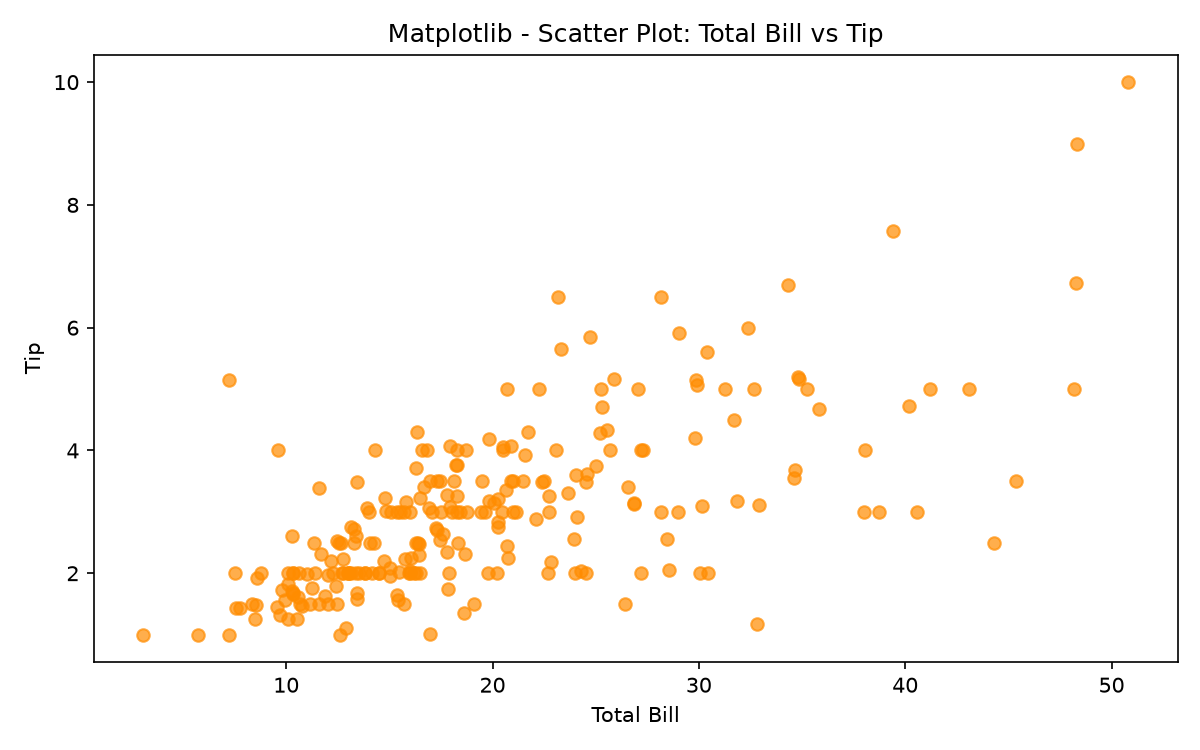

### Short Insights – Matplotlib Scatter Plot

* There is a **positive relationship** between total bill and tip.
* As the **total bill increases, the tip generally tends to increase**.
* Most data points are concentrated around **$10–$25 total bills** with tips around **$1–$4**.

* Higher bills, especially above **$30**, show a **wider range of tip values**.

* A few higher-value observations have tips reaching around **$7–$10**.

* Overall, the scatter plot suggests that **larger bills generally result in larger tips**, although the relationship is not exact.


box_data = []

for d in ['Sun', 'Sat', 'Thur', 'Fri']:
    data = tips[tips['day'] == d]['total_bill']
    box_data.append(data)
Original tips

box_data
   │
   ├── Sunday total_bill values
   │
   ├── Saturday total_bill values
   │
   ├── Thursday total_bill values
   │
   └── Friday total_bill values

Day       Total Bill
Sun          16.99       ← keep
Sat          20.50       ← remove
Sun          25.30       ← keep
Fri          18.20       ← remove
Sun          22.10       ← keep

tips[tips['day'] == 'Sun']['total_bill']
16.99
25.30
22.10
...

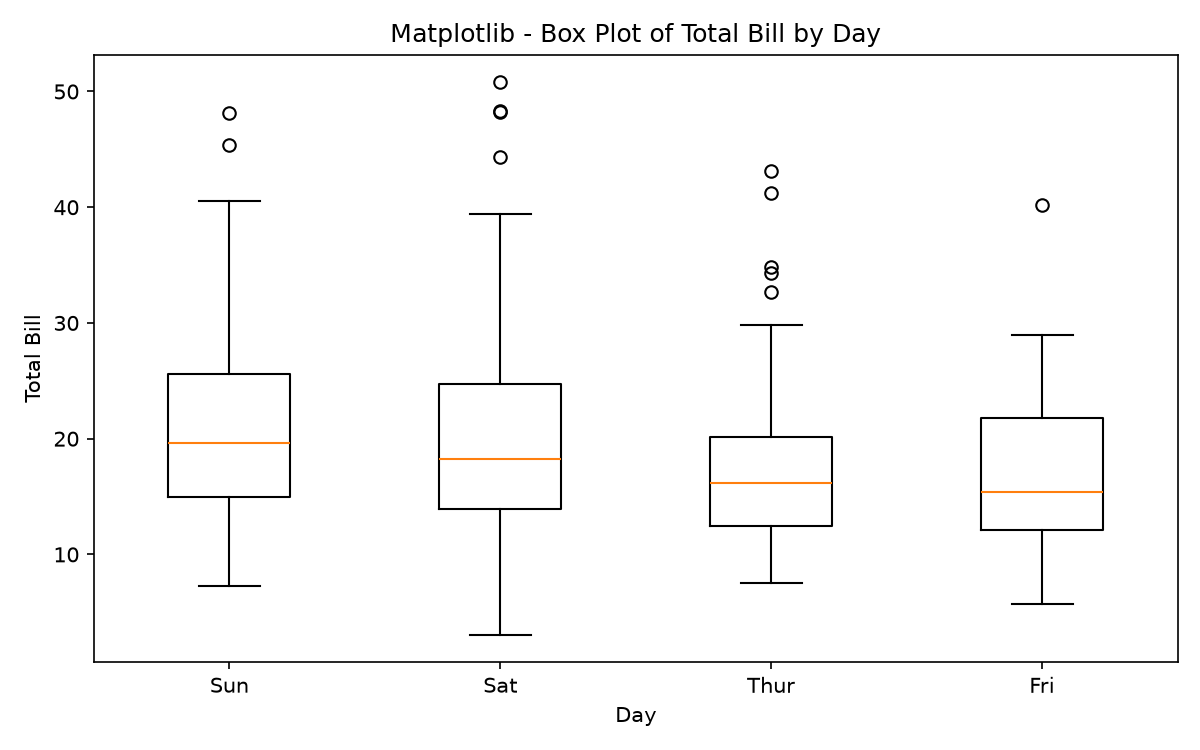

### Short Insights – Matplotlib Box Plot

* **Sunday has the highest median total bill**, at approximately **$19.7**.

* **Saturday** has a slightly lower median, around **$18.2**, but shows a wide spread of bill amounts.

* **Thursday and Friday** have lower median bills, around **$16–$17**.

* **Saturday has the widest overall range**, with bills extending from around **$3 to above $50**.

* All four days have **high-value outliers**, showing some unusually large bills.

* **Saturday and Sunday** generally have higher bill distributions compared with Thursday and Friday.


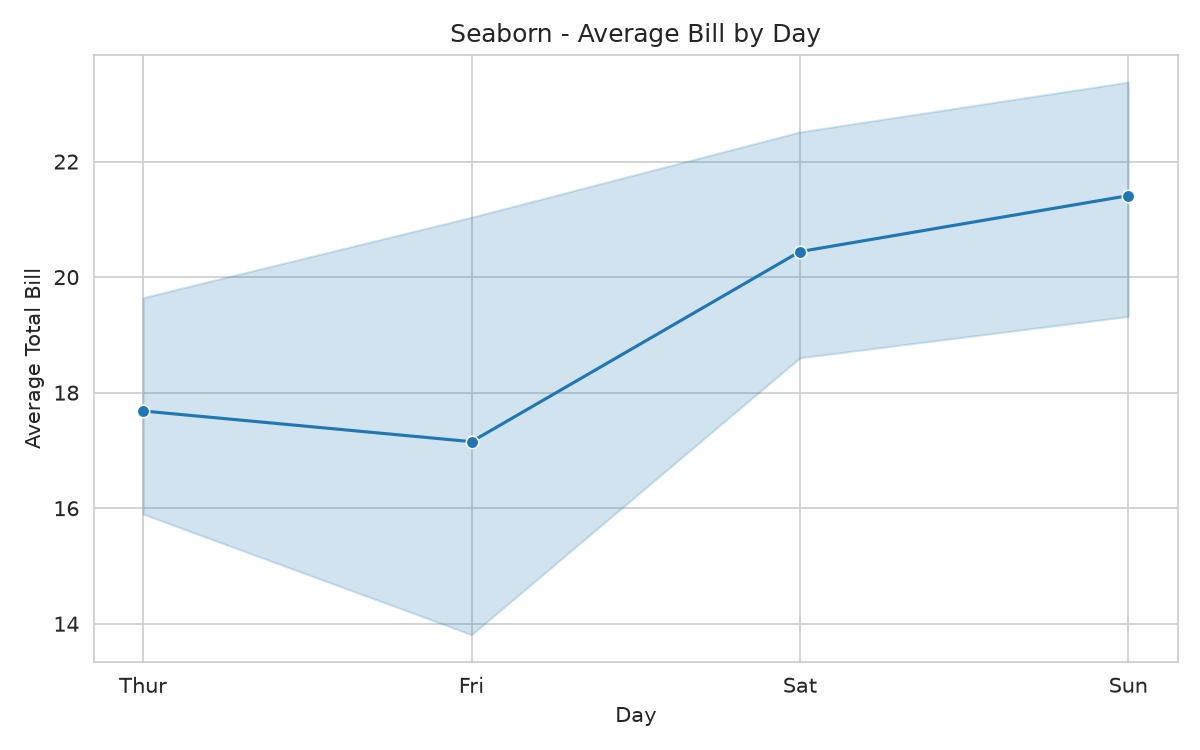

The important point is that you don't have to manually use groupby() here. sns.lineplot() handles the grouping and aggregation because you specified estimator='mean'.

tips
  ↓
Look at x='sex'
  ↓
Find unique categories
  ↓
Male       Female
  ↓           ↓
take their total_bill values
  ↓           ↓
calculate mean
  ↓           ↓
Male average   Female average

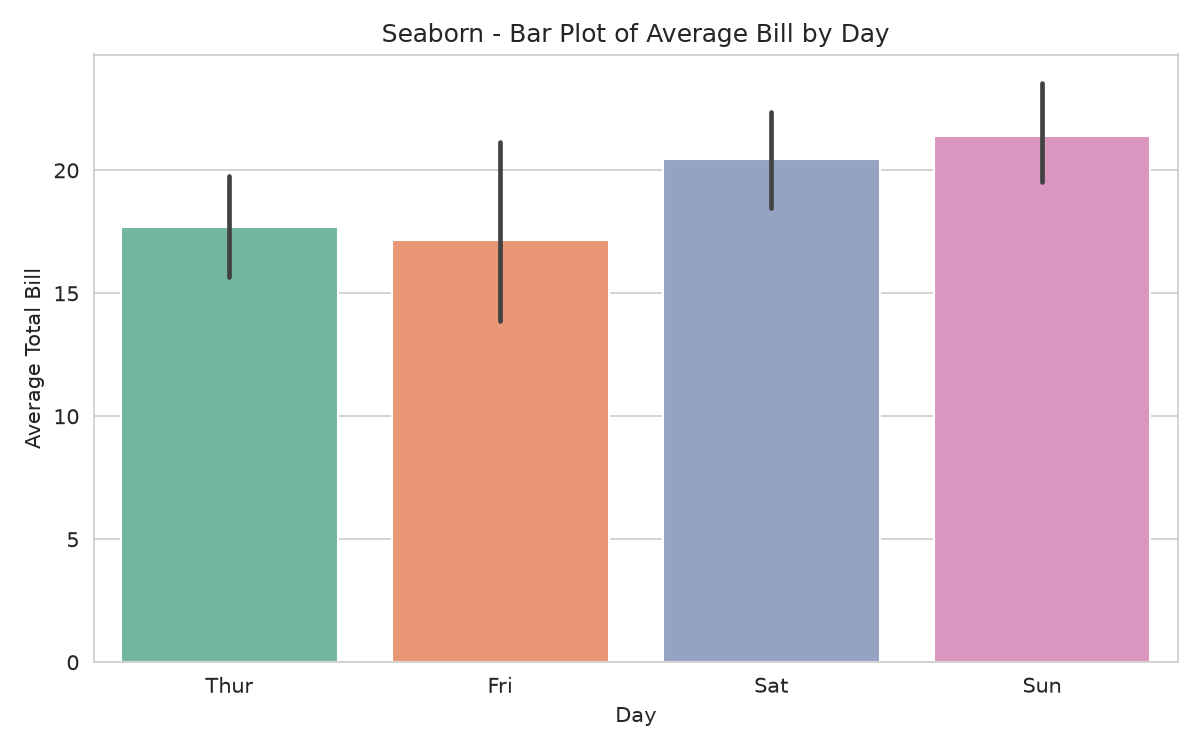

Use Seaborn's predefined Set2 color palette for the different categories.

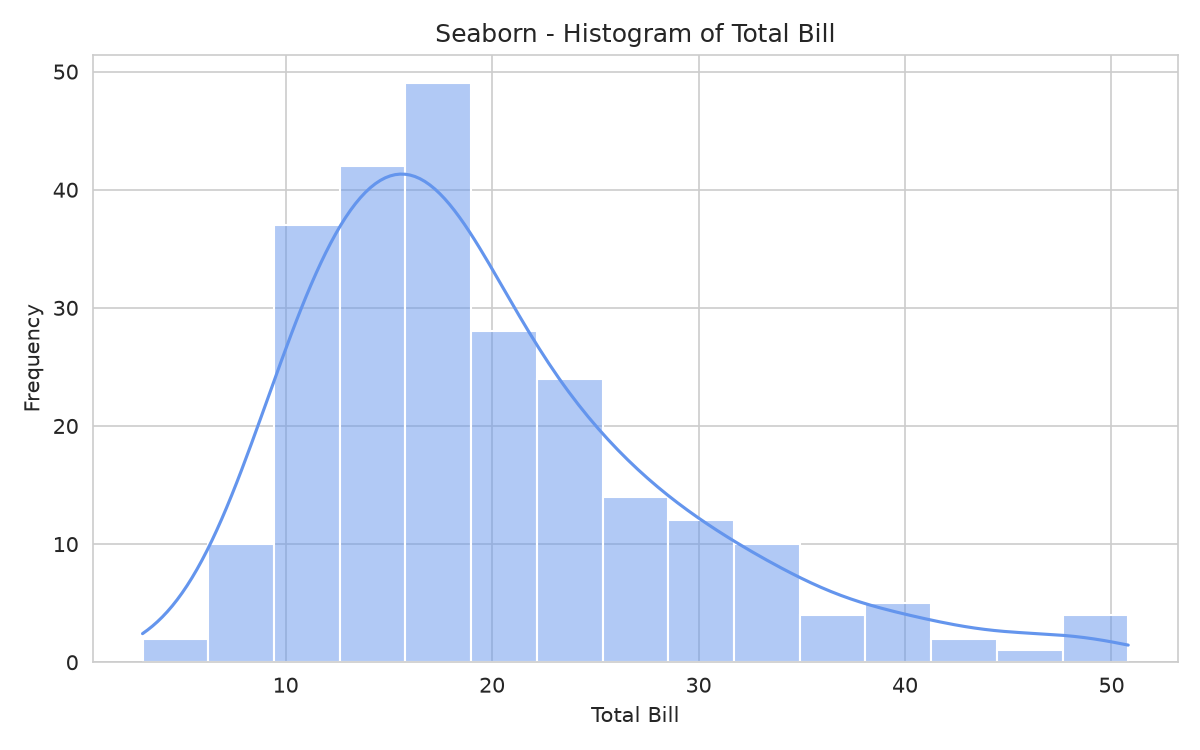

1. bins=15

bins controls how many groups/ranges the data is divided into.

kde means Kernel Density Estimate.

kde=True

tells Seaborn:

Add a smooth curve showing the overall distribution of the data

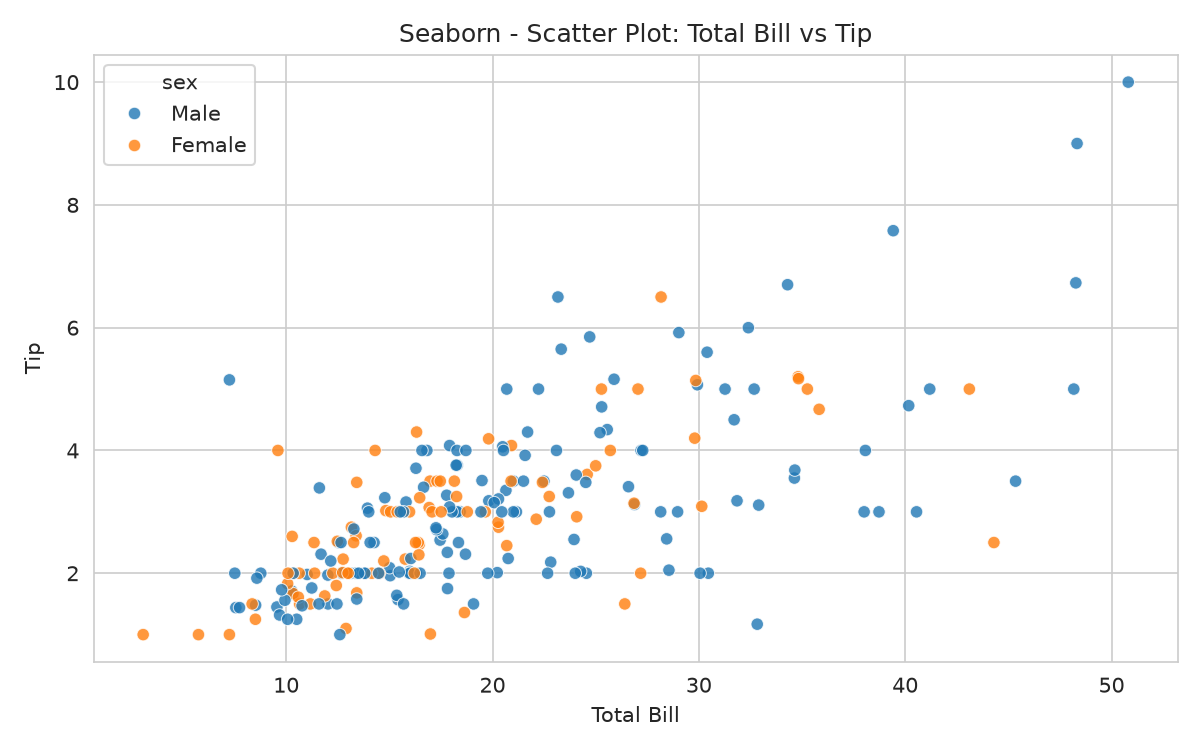

This is similar to the Matplotlib scatter plot, but now
hue='sex'
Use different visual categories for different sex values.
So the scatter plot now provides an additional dimension of information
alpha=0.8 controls the transparency of the scatter points.

alpha=1 → completely solid
alpha=0.8 → slightly transparent
alpha=0 → completely invisible

So here, alpha=0.8 makes overlapping points easier to see
### Short Insights – Seaborn Scatter Plot

* There is a **positive relationship** between total bill and tip: higher bills generally have higher tips.

* Most observations are concentrated around **$10–$25 total bills** and **$1–$4 tips**.

* **Male customers** have more observations at higher bill and tip values in this dataset.

* Some of the **highest tips (around $7–$10)** are associated with higher total bills.

* Female observations are mostly concentrated at **lower to moderate bill and tip values**, with some exceptions.

* Overall, the plot shows that **bill amount is generally associated with tip amount**, but there is noticeable variation.


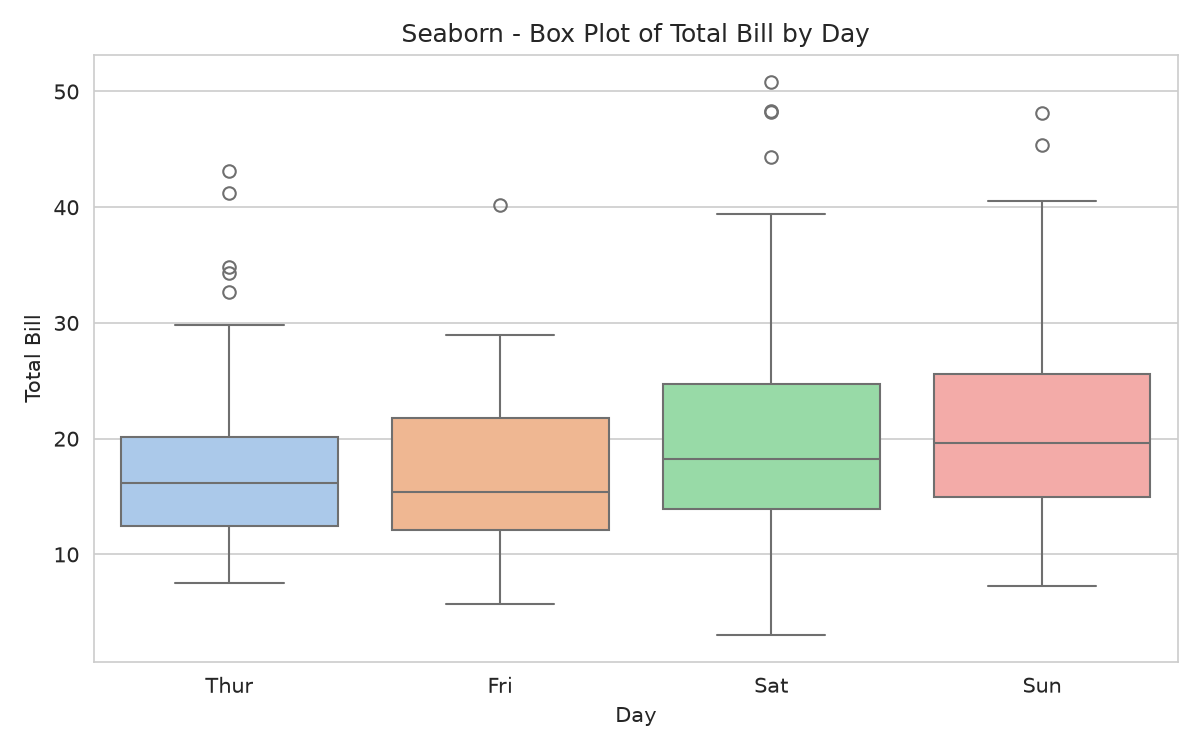

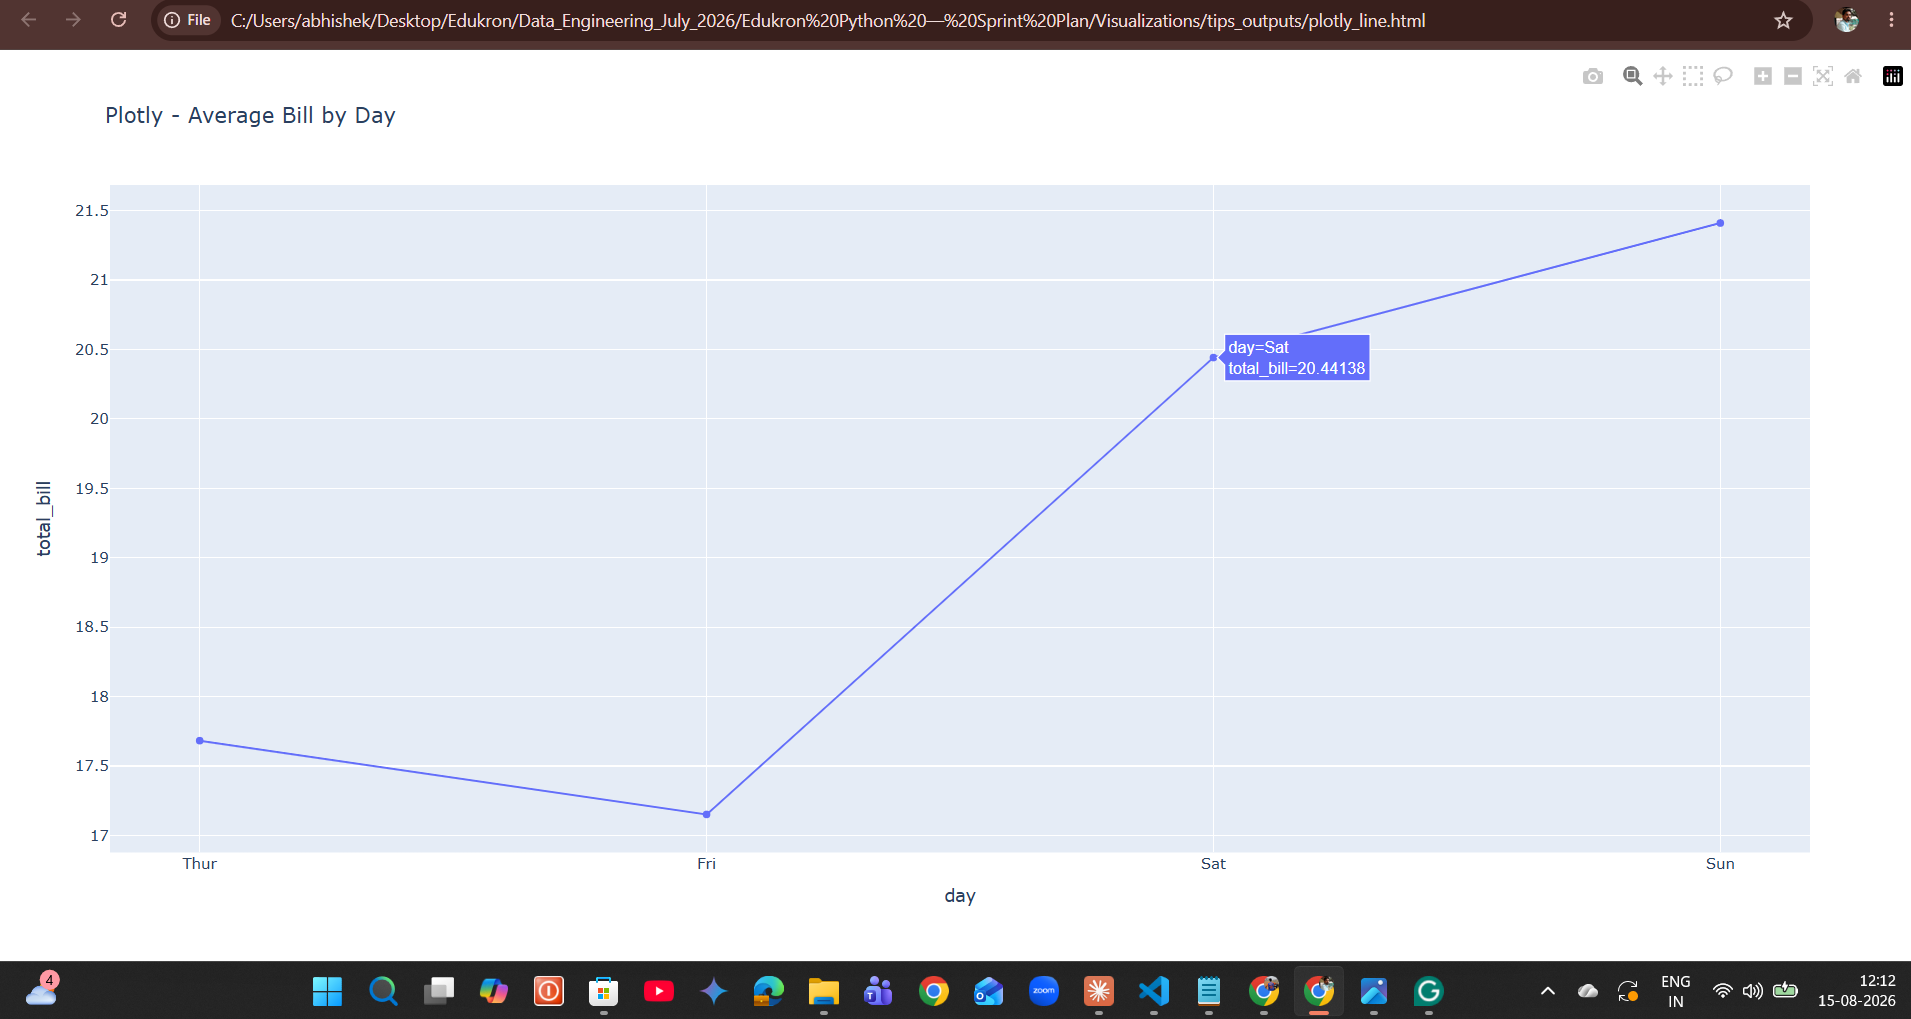

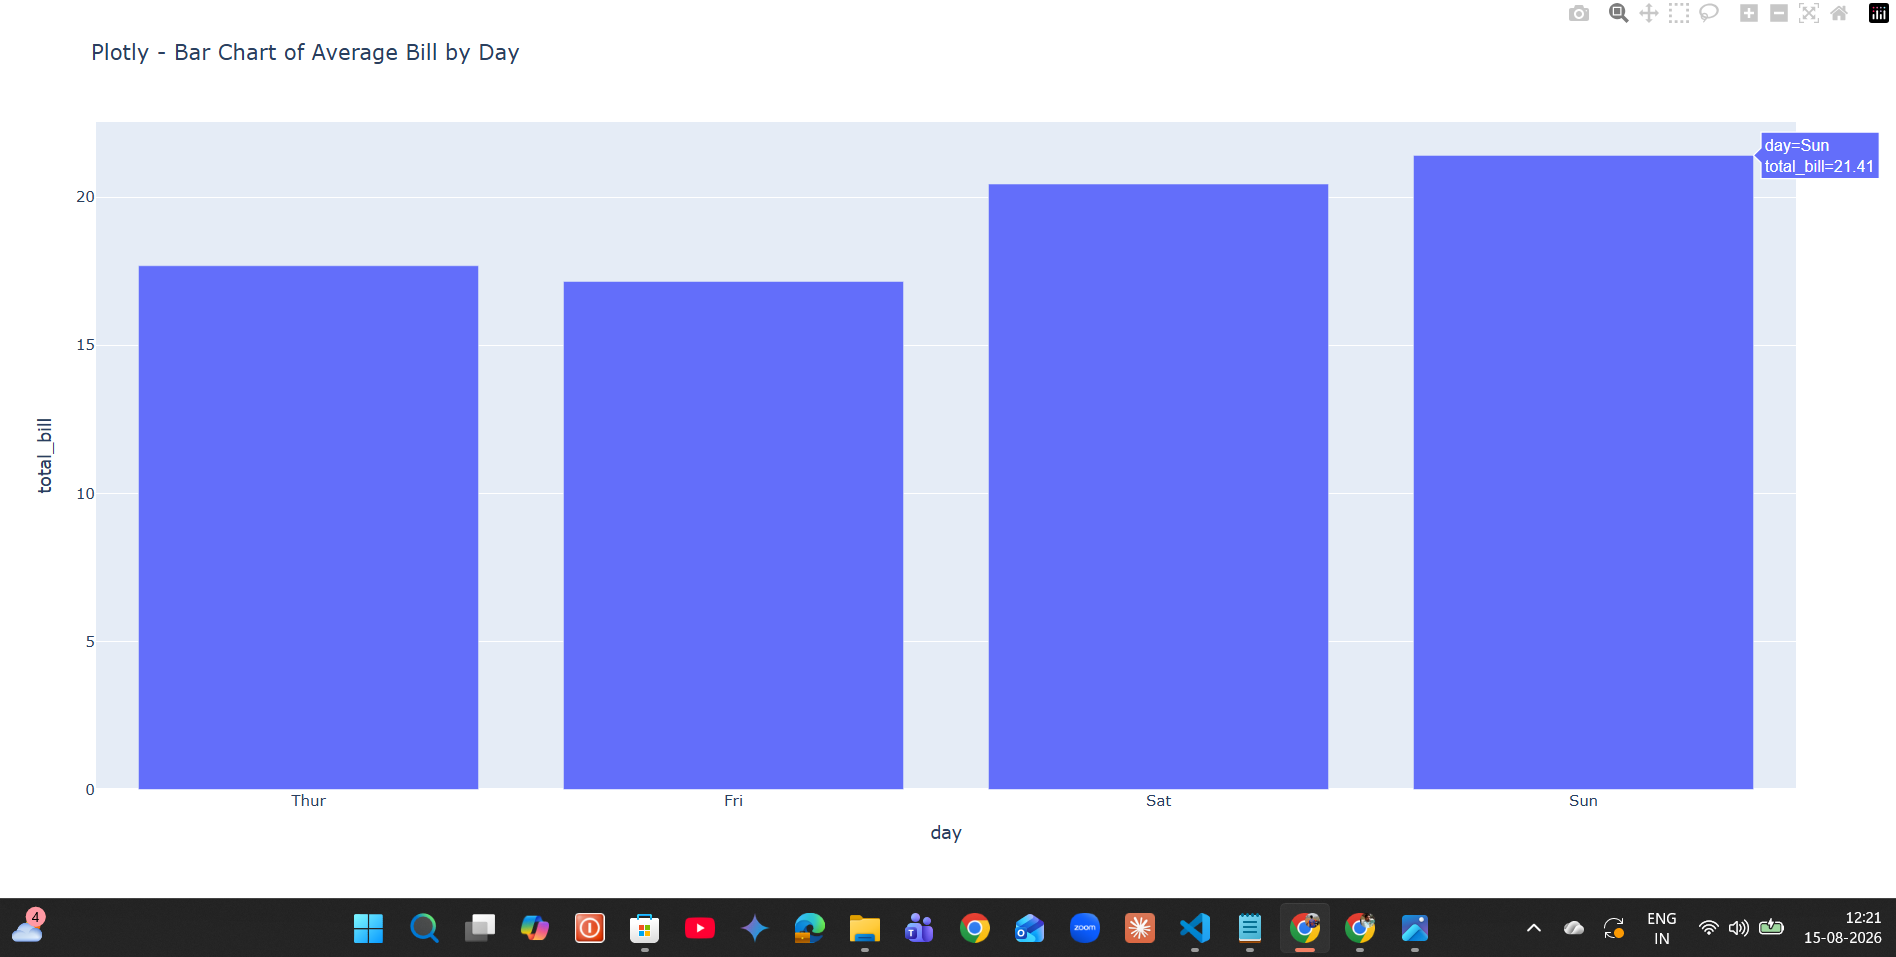

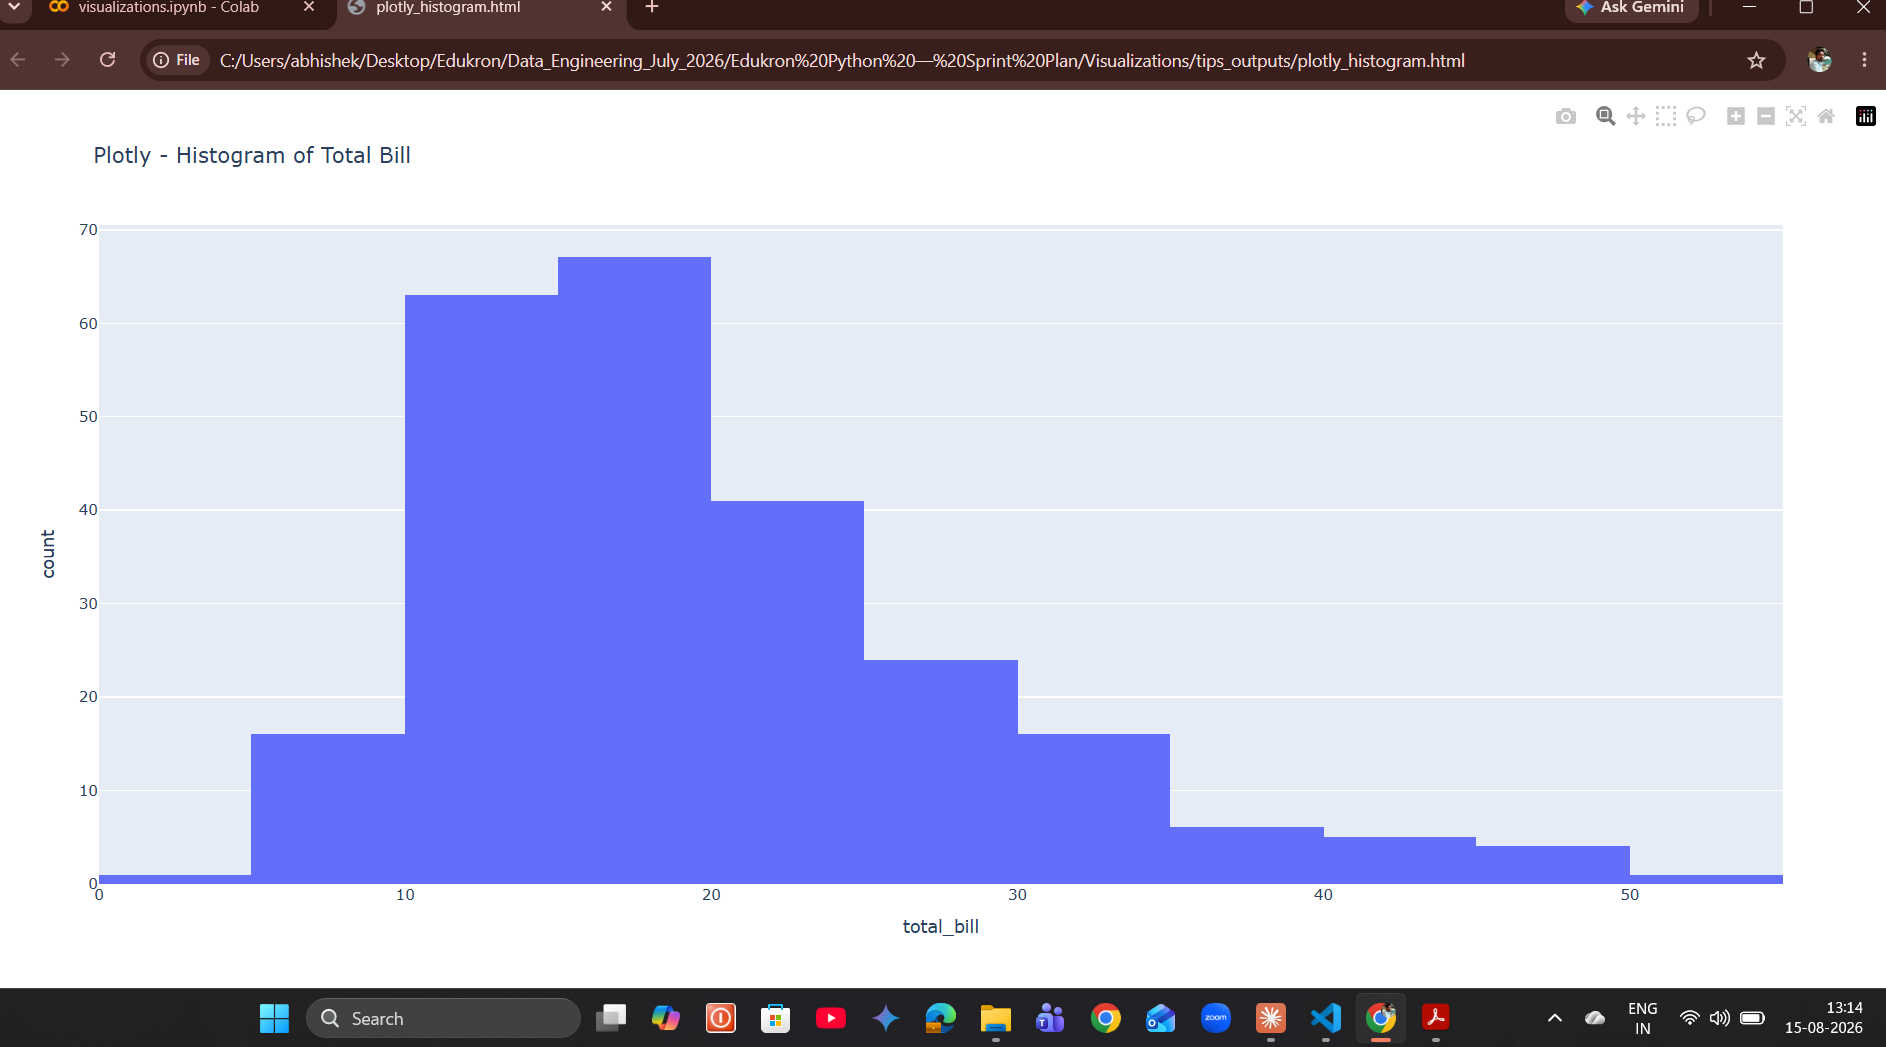

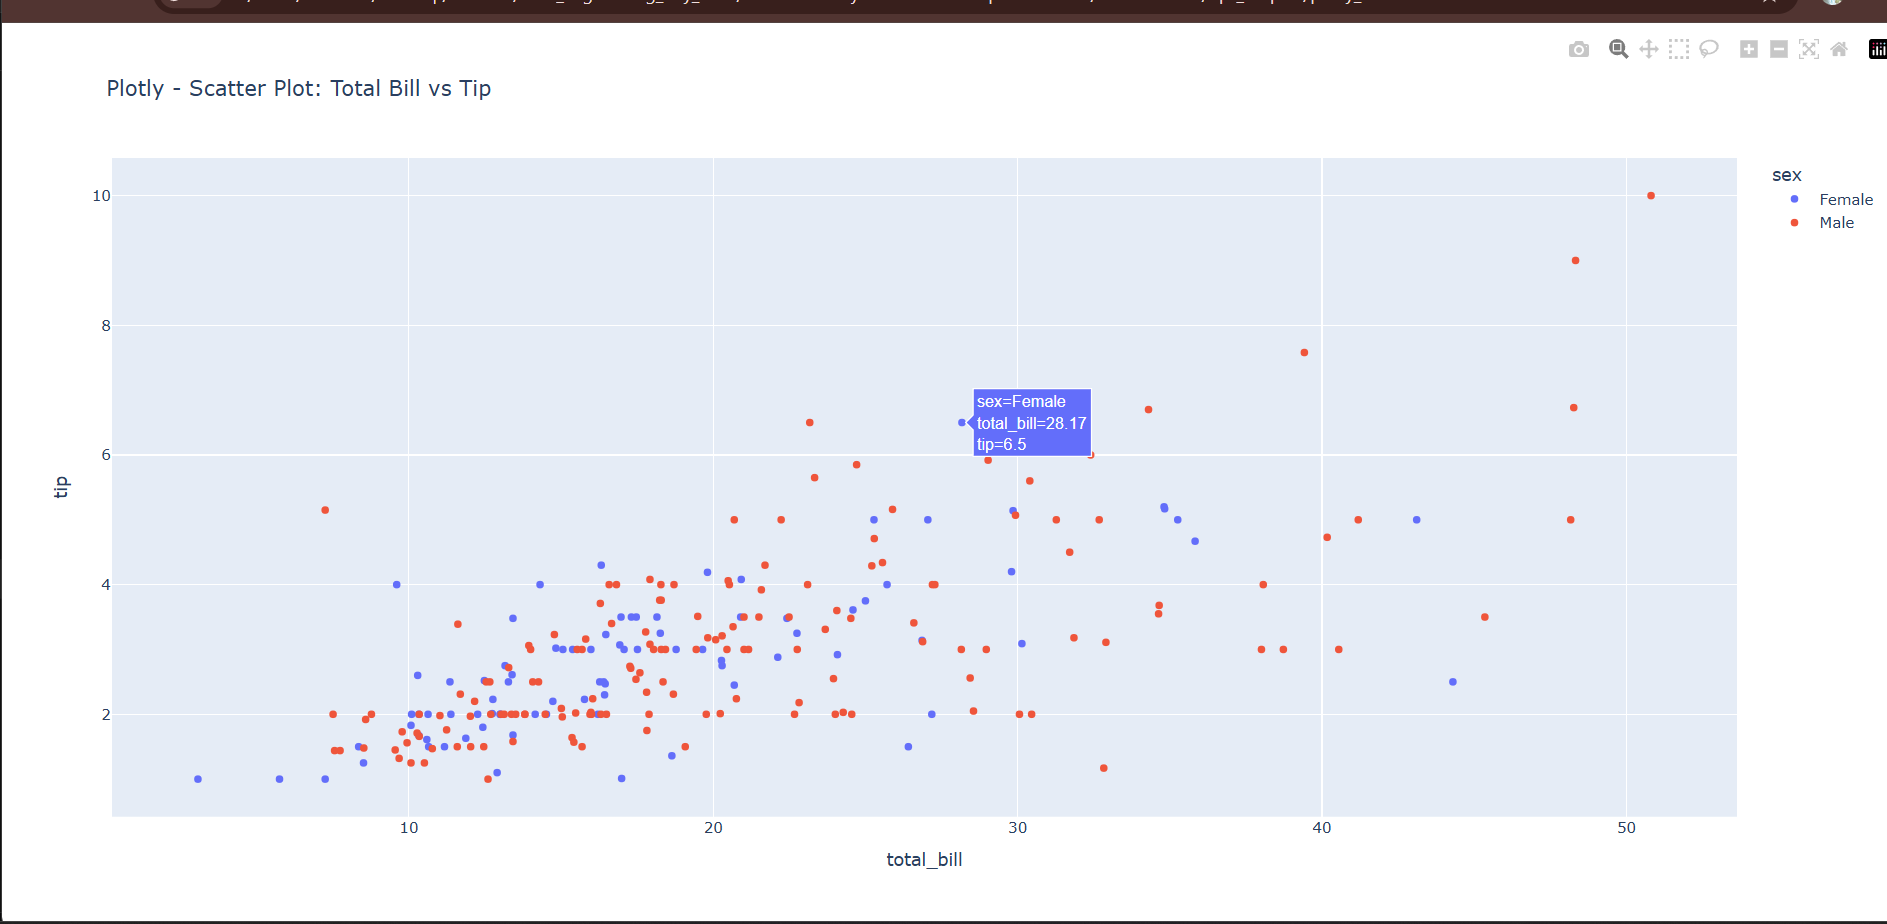

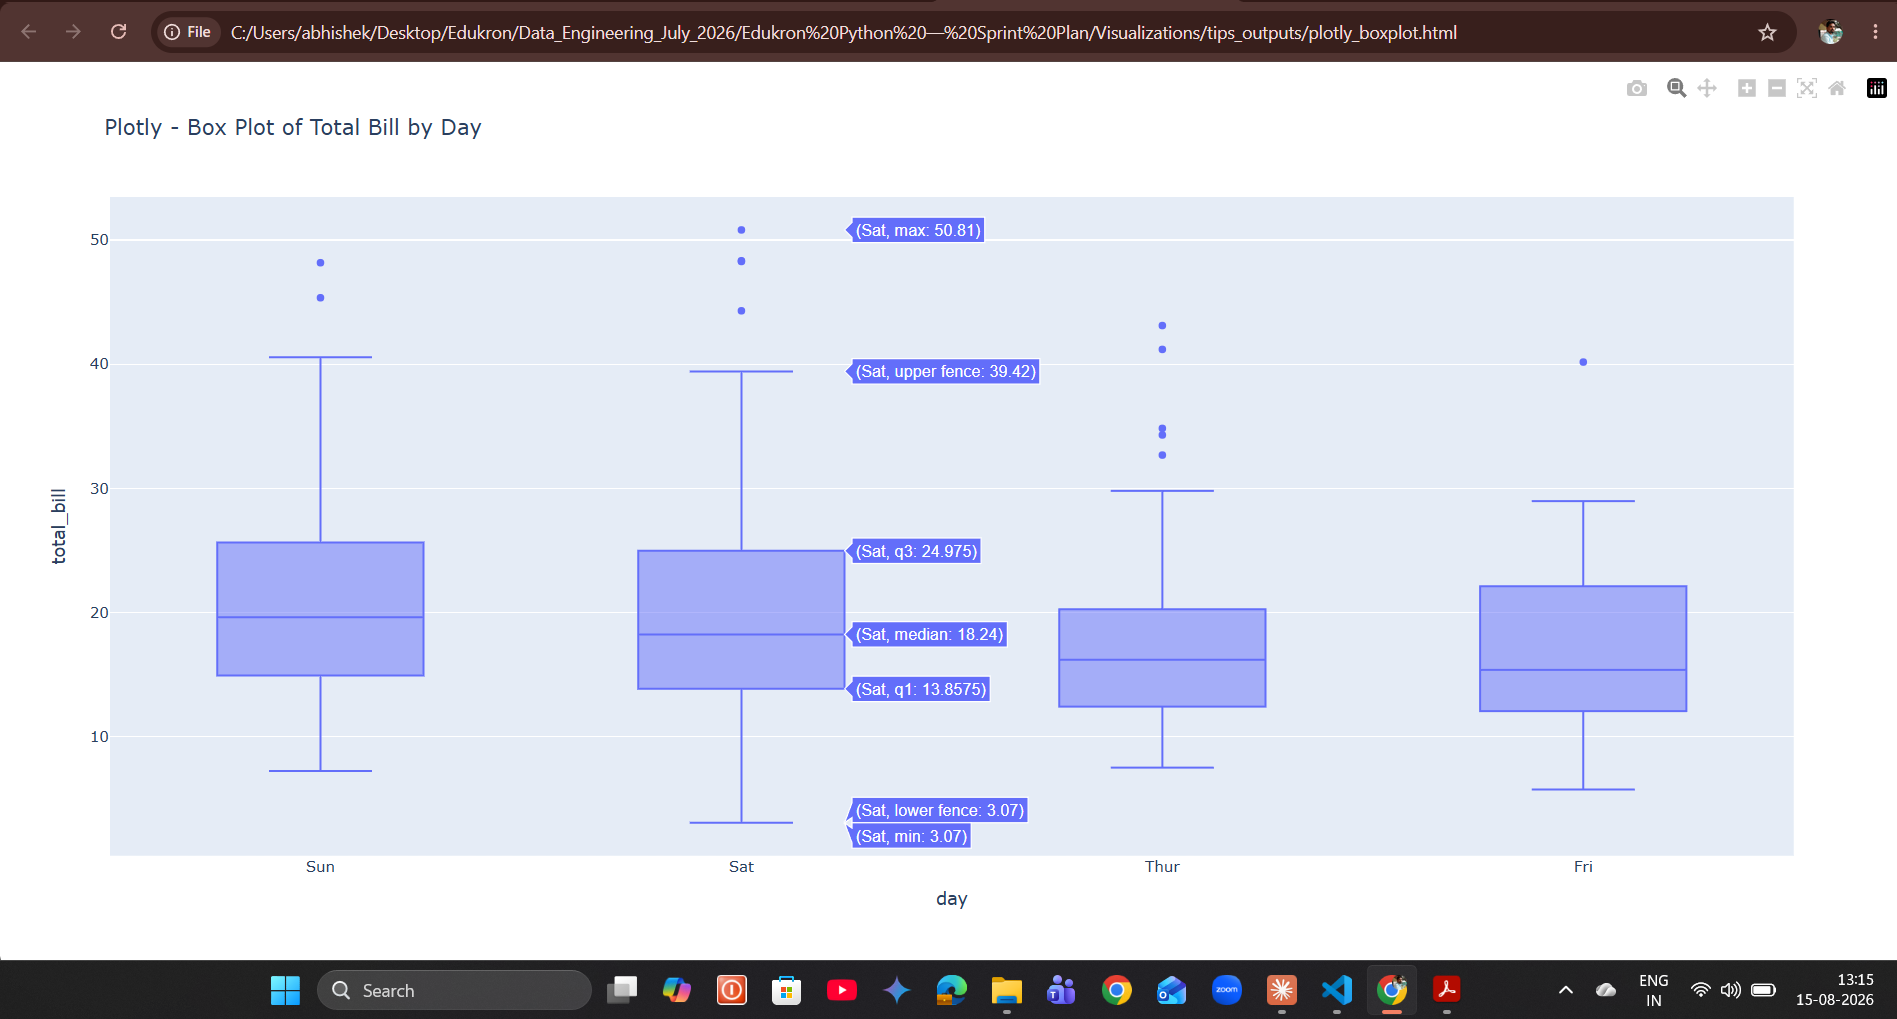

1. Sunday has the highest typical spend. Its median (~19.6) and its box sit higher than every other day, so a Sunday customer usually spends more than a Thursday or Friday one.

2. Saturday has the widest spread. Its box stretches from about 13.86 to 24.98 (an IQR of ~11), and its whiskers run from 3.07 all the way to 39.42 — the most unpredictable day of the four.

3. The biggest single bill of the week is on Saturday at 50.81 — an outlier well above its upper fence of 39.42.

4. Thursday has the most outliers. Five or six points sit above its whisker (roughly 32–43) while its box is comparatively low and tight, suggesting a mostly modest-spending day punctuated by a few unusually large tables.

5. Weekends beat weekdays, but not dramatically. Sunday and Saturday sit higher than Thursday and Friday, yet all four medians land between roughly 15 and 20 — the boxes overlap heavily, so day alone is a weak predictor of bill size

The most important concepts to learn from this file are:
1. sns.load_dataset() → load sample data
2. groupby() + mean() → calculate average by category
3. plt.subplots() → create a Matplotlib figure
4. plot() , bar() , hist() , scatter() , boxplot() → different chart types
5. Seaborn → easier statistical visualization
6. Plotly → interactive visualization
7. savefig() → save Matplotlib graph
8. write_html() → save Plotly graph
9. os.path.join() → construct file paths
10. os.makedirs() → create output directory